# Advanced Scientific Computing and Machine Learning Guide
This notebook covers fundamental tools for advanced scientific data processing, curve fitting, optimization, and foundational classification models in Python using SciPy and Scikit-Learn.

## 1. SciPy: Numerical Integration & Optimization
SciPy provides core algorithms for scientific computing, including numerical integration, optimization, statistics, and signal processing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import curve_fit

# Define a test function for numerical integration: f(x) = x^2
def integrand(x):
    return x**2

# Compute the definite integral from 0 to 3
result, error = quad(integrand, 0, 3)
print(f"Integral result: {result} (Estimated error: {error})")

Integral result: 9.0 (Estimated error: 9.992007221626409e-14)


### Experimental Curve Fitting
Using `curve_fit` to extract physical parameters from noisy experimental data by fitting a target theoretical model function.

Optimized parameters -> a: 2.393, b: 1.302


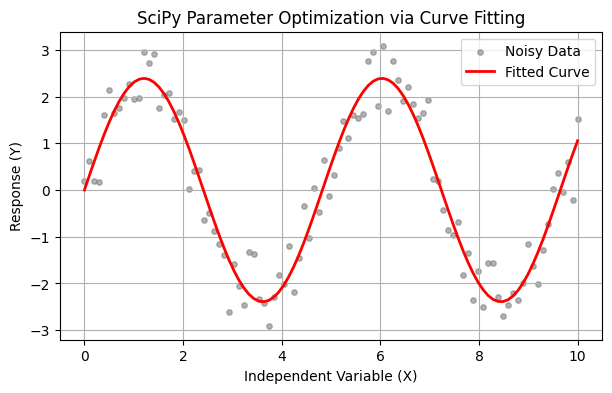

In [ ]:
# Define the theoretical model function: f(x) = a * sin(b * x)
def model_func(x, a, b):
    return a * np.sin(b * x)

# Generate noisy experimental data
x_data = np.linspace(0, 10, 100)
y_clean = 2.5 * np.sin(1.3 * x_data)
noise = np.random.normal(0, 0.5, len(x_data))
y_data = y_clean + noise

# Fit the model function to the experimental data
popt, pcov = curve_fit(model_func, x_data, y_data, p0=[2, 1])
print(f"Optimized parameters -> a: {popt[0]:.3f}, b: {popt[1]:.3f}")

# Plot the results
plt.figure(figsize=(7, 4))
plt.scatter(x_data, y_data, label='Noisy Data', color='gray', alpha=0.6, s=15)
plt.plot(x_data, model_func(x_data, *popt), label='Fitted Curve', color='red', linewidth=2)
plt.legend()
plt.title("SciPy Parameter Optimization via Curve Fitting")
plt.xlabel("Independent Variable (X)")
plt.ylabel("Response (Y)")
plt.grid(True)
plt.show()

## 2. Scikit-Learn: Classification Tasks
Scikit-Learn is the standard library for implementing supervised and unsupervised machine learning algorithms in Python.

### A. Single Decision Tree Classifier
A hierarchical model that partitions data based on feature thresholds to assign objects into predefined, mutually exclusive categories.

--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



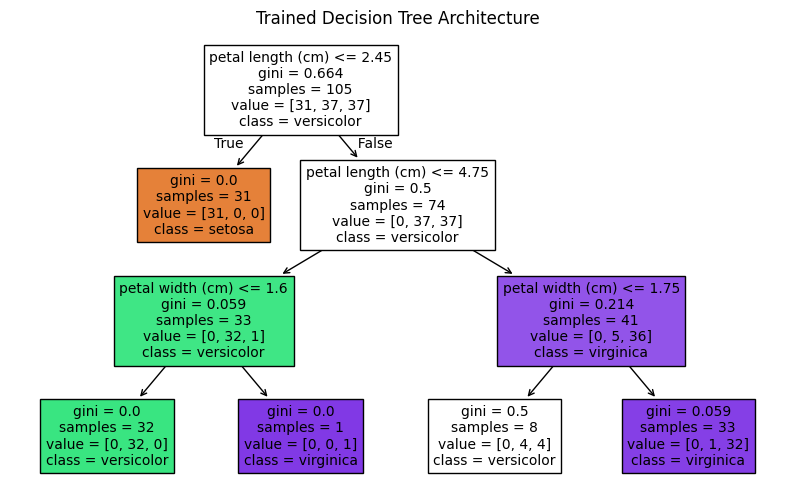

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report

# Load the benchmark Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Decision Tree
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

# Evaluate performance
y_pred_tree = tree_model.predict(X_test)
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_tree, target_names=iris.target_names))

# Visualize the trained decision tree structure
plt.figure(figsize=(10, 6))
plot_tree(tree_model, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.title("Trained Decision Tree Architecture")
plt.show()

### B. Random Forest Classifier
An ensemble learning method that builds a collection of independent decision trees to reduce variance, improve generalization, and mitigate overfitting.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest ensemble model
forest_model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
forest_model.fit(X_train, y_train)

# Evaluate performance
y_pred_forest = forest_model.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_forest, target_names=iris.target_names))

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

